# Model V3: Regression Approach

Instead of treating condition as 5 discrete classes, treat it as a continuous value and use MSE loss. At inference, round to the nearest integer.

**Hypothesis:** Regression naturally respects ordering (predicting 4.2 when true is 5.0 costs less than predicting 1.0) without needing the ordinal soft-label machinery. But it may struggle with the discrete nature of human ratings.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Device: {DEVICE}")

CSV_PATH = Path("../data/cleaned_metadata_v2.csv")
df = pd.read_csv(CSV_PATH)
train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]
print(f"Train: {len(train_df):,}  Test: {len(test_df):,}")

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Train: 25,548  Test: 6,388


In [2]:
IMG_SIZE = 260
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=20, scale=(0.85, 1.15), shear=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class ClothingDatasetRegression(Dataset):
    """Returns condition as a float target scaled to [0, 1] for regression."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        front = Image.open(row["front_path"]).convert("RGB")
        back  = Image.open(row["back_path"]).convert("RGB")
        if self.transform:
            front = self.transform(front)
            back  = self.transform(back)
        # Scale condition 1-5 → 0.0-1.0 for stable MSE training
        condition_scaled = (row["condition"] - 1) / 4.0
        labels = {
            "condition": torch.tensor(condition_scaled, dtype=torch.float),
            "condition_class": torch.tensor(row["condition"] - 1, dtype=torch.long),
            "stains": torch.tensor(row["stains"], dtype=torch.long),
            "holes":  torch.tensor(row["holes"],  dtype=torch.long),
            "pilling": torch.tensor(row["pilling"] - 1, dtype=torch.long),
        }
        return front, back, labels


train_loader = DataLoader(ClothingDatasetRegression(train_df, train_transforms),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(ClothingDatasetRegression(test_df, test_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_loader)} batches  Test: {len(test_loader)} batches")

Train: 799 batches  Test: 200 batches


In [3]:
class ClothingRegressionModel(nn.Module):
    """
    Same dual-stream EfficientNet-B2, but condition head outputs a single
    continuous value instead of 5 class logits.
    """
    def __init__(self, backbone_name="efficientnet_b2", pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            in_chans=3, num_classes=0, global_pool="avg",
        )
        feat_dim = self.backbone.num_features
        cd = feat_dim * 2

        # Regression head: outputs single value in [0, 1]
        self.condition_head = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(cd, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, 1), nn.Sigmoid(),
        )
        # Auxiliary heads (same as V2)
        self.stains_head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(cd, 64), nn.ReLU(inplace=True), nn.Linear(64, 3))
        self.holes_head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(cd, 64), nn.ReLU(inplace=True), nn.Linear(64, 3))
        self.pilling_head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(cd, 64), nn.ReLU(inplace=True), nn.Linear(64, 5))

    def forward(self, front, back):
        f_f = self.backbone(front)
        f_b = self.backbone(back)
        c = torch.cat([f_f, f_b], dim=1)
        return {
            "condition": self.condition_head(c).squeeze(-1),  # (B,)
            "stains": self.stains_head(c),
            "holes": self.holes_head(c),
            "pilling": self.pilling_head(c),
        }

model = ClothingRegressionModel(pretrained=True).to(DEVICE)

# Freeze backbone initially
for p in model.backbone.parameters():
    p.requires_grad = False

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total: {total:,}  Trainable: {trainable:,} (backbone frozen)")

Total: 8,963,982  Trainable: 1,262,988 (backbone frozen)


In [4]:
# ── Loss & optimizer setup ────────────────────────────────────────────────────

# Compute class weights for auxiliary heads (same as V2)
def inverse_freq_weights(series, num_classes, max_weight=10.0):
    counts = series.value_counts().sort_index()
    total = len(series)
    weights = [min(total / (num_classes * counts.get(c, 1)), max_weight) for c in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float32)

stains_weights = inverse_freq_weights(train_df["stains"], 3).to(DEVICE)
holes_weights  = inverse_freq_weights(train_df["holes"], 3).to(DEVICE)

condition_criterion = nn.MSELoss()
stains_criterion = nn.CrossEntropyLoss(weight=stains_weights)
holes_criterion  = nn.CrossEntropyLoss(weight=holes_weights)
pilling_criterion = nn.CrossEntropyLoss()

HEAD_LR = 1e-3
BACKBONE_LR = 1e-4
NUM_EPOCHS = 15
UNFREEZE_AT = 3
PATIENCE = 4
SAVE_DIR = Path("../checkpoints_regression")
SAVE_DIR.mkdir(exist_ok=True)

USE_AMP = DEVICE.type in ("cuda", "mps")
amp_dtype = torch.float16

head_params = [p for n, p in model.named_parameters() if "backbone" not in n]
optimizer = torch.optim.AdamW(head_params, lr=HEAD_LR, weight_decay=1e-4)

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=HEAD_LR,
    epochs=NUM_EPOCHS, steps_per_epoch=steps_per_epoch,
    pct_start=0.1, anneal_strategy="cos",
)

def unfreeze_backbone(model, optimizer, remaining_epochs, steps_per_epoch):
    for p in model.backbone.parameters():
        p.requires_grad = True
    optimizer.add_param_group({"params": list(model.backbone.parameters()),
                               "lr": BACKBONE_LR, "weight_decay": 1e-4})
    new_sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[HEAD_LR * 0.5, BACKBONE_LR],
        epochs=remaining_epochs, steps_per_epoch=steps_per_epoch,
        pct_start=0.05, anneal_strategy="cos")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  ★ Backbone unfrozen — trainable params: {trainable:,}")
    return new_sched

print("Ready to train.")

Ready to train.


In [5]:
# ── Training loop ─────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, total_n = 0.0, 0
    for fronts, backs, labels in tqdm(loader, desc="  train", leave=False):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        cond_target = labels["condition"].to(DEVICE)
        stains_t = labels["stains"].to(DEVICE)
        holes_t  = labels["holes"].to(DEVICE)
        pilling_t = labels["pilling"].to(DEVICE)

        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
            out = model(fronts, backs)
            cond_loss = condition_criterion(out["condition"], cond_target)
            s_loss = stains_criterion(out["stains"], stains_t)
            h_loss = holes_criterion(out["holes"], holes_t)
            p_loss = pilling_criterion(out["pilling"], pilling_t)
            loss = 0.6 * cond_loss + 0.15 * s_loss + 0.15 * h_loss + 0.1 * p_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * fronts.size(0)
        total_n += fronts.size(0)
        if DEVICE.type == "mps":
            torch.mps.synchronize()

    return total_loss / total_n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds_raw = []
    all_targets = []
    total_loss, total_n = 0.0, 0

    for fronts, backs, labels in tqdm(loader, desc="  eval", leave=False):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        cond_target = labels["condition"].to(DEVICE)
        cond_class  = labels["condition_class"]

        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
            out = model(fronts, backs)
            loss = condition_criterion(out["condition"], cond_target)

        # Convert [0,1] prediction back to [0,4] class index
        pred_continuous = out["condition"].cpu().numpy() * 4.0
        pred_classes = np.clip(np.round(pred_continuous), 0, 4).astype(int)

        all_preds_raw.append(pred_continuous)
        all_targets.append(cond_class.numpy())
        total_loss += loss.item() * fronts.size(0)
        total_n += fronts.size(0)

    all_preds_raw = np.concatenate(all_preds_raw)
    all_targets = np.concatenate(all_targets)
    pred_classes = np.clip(np.round(all_preds_raw), 0, 4).astype(int)

    acc = (pred_classes == all_targets).mean()
    mae = np.abs(pred_classes - all_targets).mean()
    one_off = (np.abs(pred_classes - all_targets) <= 1).mean()
    # Also compute continuous MAE (before rounding)
    continuous_mae = np.abs(all_preds_raw - all_targets).mean()

    return {
        "loss": total_loss / total_n,
        "acc": acc, "mae": mae, "one_off": one_off,
        "continuous_mae": continuous_mae,
        "preds": pred_classes, "targets": all_targets,
        "preds_raw": all_preds_raw,
    }

print("Training functions defined.")

Training functions defined.


In [6]:
# ── Main training loop ────────────────────────────────────────────────────────

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_mae": [], "val_one_off": []}
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == UNFREEZE_AT:
        remaining = NUM_EPOCHS - epoch + 1
        scheduler = unfreeze_backbone(model, optimizer, remaining, steps_per_epoch)

    lrs = " / ".join(f"{g['lr']:.2e}" for g in optimizer.param_groups)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lrs})")

    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val = evaluate(model, test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_mae"].append(val["mae"])
    history["val_one_off"].append(val["one_off"])

    print(f"  train_loss={train_loss:.4f}")
    print(f"  val  acc={val['acc']:.4f}  MAE={val['mae']:.3f}  1-off={val['one_off']:.4f}  "
          f"continuous_MAE={val['continuous_mae']:.3f}")

    checkpoint = {"epoch": epoch, "model_state_dict": model.state_dict(),
                  "history": history, "best_val_loss": best_val_loss}
    torch.save(checkpoint, SAVE_DIR / "last_checkpoint.pt")

    if val["loss"] < best_val_loss:
        best_val_loss = val["loss"]
        patience_counter = 0
        torch.save(checkpoint, SAVE_DIR / "best_checkpoint.pt")
        print(f"  ✓ saved best (val_loss={val['loss']:.4f})")
    else:
        patience_counter += 1
        print(f"  ✗ no improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

print(f"\nDone. Best val loss: {best_val_loss:.4f}")


Epoch 1/15  (lr=4.00e-05)


  train_loss=0.4812
  val  acc=0.3259  MAE=0.872  1-off=0.8162  continuous_MAE=0.914
  ✓ saved best (val_loss=0.0749)

Epoch 2/15  (lr=7.61e-04)


  train_loss=0.4668
  val  acc=0.3651  MAE=0.842  1-off=0.7984  continuous_MAE=0.902
  ✓ saved best (val_loss=0.0739)
  ★ Backbone unfrozen — trainable params: 8,963,982

Epoch 3/15  (lr=2.00e-05 / 4.00e-06)


  train_loss=0.4543
  val  acc=0.3505  MAE=0.830  1-off=0.8286  continuous_MAE=0.875
  ✓ saved best (val_loss=0.0709)

Epoch 4/15  (lr=4.99e-04 / 9.98e-05)


  train_loss=0.4408
  val  acc=0.3316  MAE=0.842  1-off=0.8386  continuous_MAE=0.886
  ✗ no improvement (1/4)

Epoch 5/15  (lr=4.85e-04 / 9.71e-05)


  train_loss=0.4308
  val  acc=0.3410  MAE=0.827  1-off=0.8427  continuous_MAE=0.865
  ✓ saved best (val_loss=0.0692)

Epoch 6/15  (lr=4.57e-04 / 9.13e-05)


KeyboardInterrupt: 

### Results & Comparison

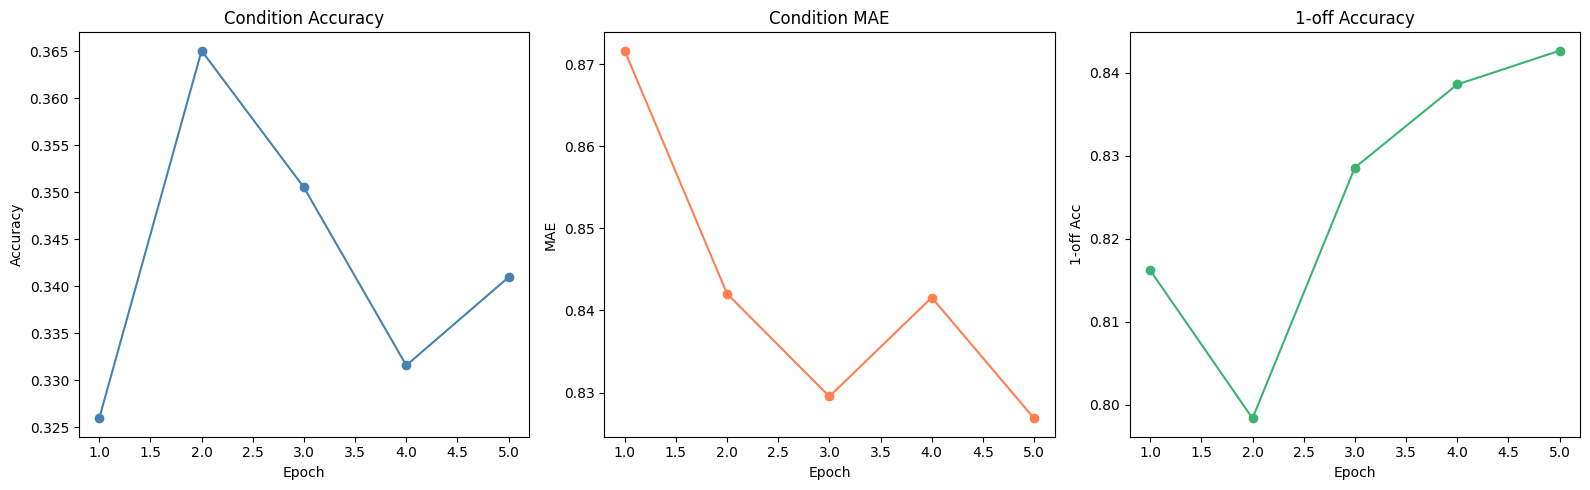

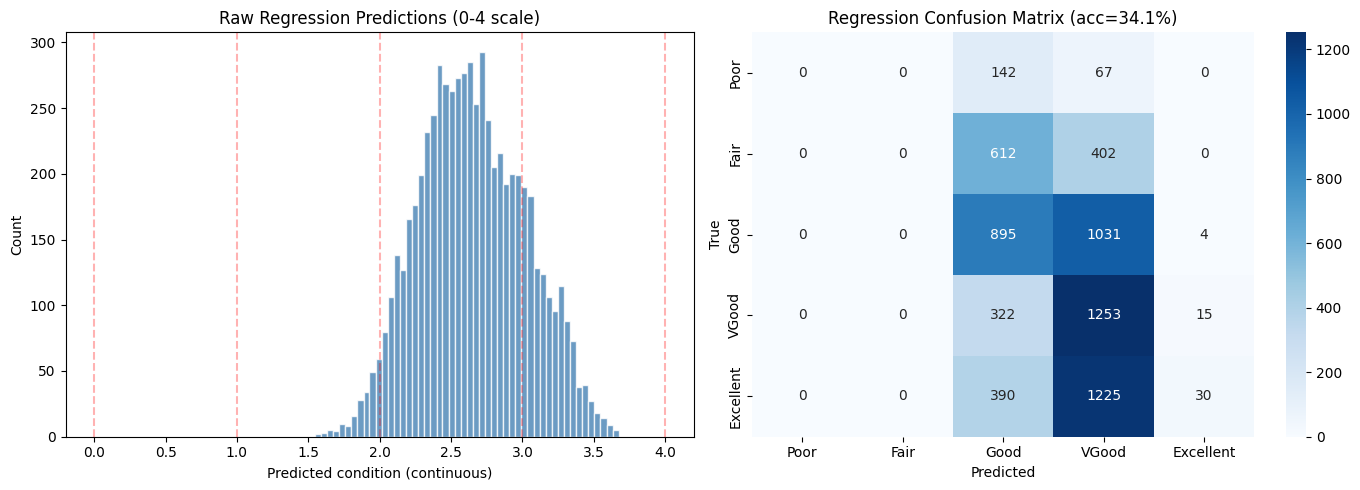

  MODEL COMPARISON
  Model                            Accuracy      MAE      1-off
  ----------------------------------------------------------
  V1 (CE, single-task)              ~0.4500      n/a        n/a
  V2 (ordinal + multi-task)          0.4050    0.812     0.8239
  V2 + TTA                           0.4106    0.796     0.8298
  V3 (regression + multi-task)       0.3410    0.827     0.8427
  CLIP zero-shot                     0.2924    0.983     0.7466
  Random                            ~0.2000   ~1.522    ~0.5200


In [7]:
# Load best checkpoint and evaluate
best_ckpt = torch.load(SAVE_DIR / "best_checkpoint.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt["model_state_dict"])
final = evaluate(model, test_loader)

FIGURES_DIR = Path("../report/figures")

# ── Training curves ───────────────────────────────────────────────────────────
h = best_ckpt["history"]
n = len(h["train_loss"])
epochs = range(1, n + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(epochs, h["val_acc"], "o-", color="steelblue")
axes[0].set_title("Condition Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")

axes[1].plot(epochs, h["val_mae"], "o-", color="coral")
axes[1].set_title("Condition MAE"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")

axes[2].plot(epochs, h["val_one_off"], "o-", color="mediumseagreen")
axes[2].set_title("1-off Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("1-off Acc")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "regression_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Prediction distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(final["preds_raw"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Raw Regression Predictions (0-4 scale)")
axes[0].set_xlabel("Predicted condition (continuous)")
axes[0].set_ylabel("Count")
for c in range(5):
    axes[0].axvline(x=c, color="red", linestyle="--", alpha=0.3)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(final["targets"], final["preds"])
import seaborn as sns
cond_labels = ["Poor", "Fair", "Good", "VGood", "Excellent"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cond_labels, yticklabels=cond_labels, ax=axes[1])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title(f"Regression Confusion Matrix (acc={final['acc']:.1%})")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "regression_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Final comparison ─────────────────────────────────────────────────────────
print("=" * 65)
print("  MODEL COMPARISON")
print("=" * 65)
print(f"  {'Model':<30} {'Accuracy':>10} {'MAE':>8} {'1-off':>10}")
print(f"  {'-'*58}")
print(f"  {'V1 (CE, single-task)':<30} {'~0.4500':>10} {'n/a':>8} {'n/a':>10}")
print(f"  {'V2 (ordinal + multi-task)':<30} {'0.4050':>10} {'0.812':>8} {'0.8239':>10}")
print(f"  {'V2 + TTA':<30} {'0.4106':>10} {'0.796':>8} {'0.8298':>10}")
print(f"  {'V3 (regression + multi-task)':<30} {final['acc']:>10.4f} {final['mae']:>8.3f} {final['one_off']:>10.4f}")
print(f"  {'CLIP zero-shot':<30} {'0.2924':>10} {'0.983':>8} {'0.7466':>10}")
print(f"  {'Random':<30} {'~0.2000':>10} {'~1.522':>8} {'~0.5200':>10}")
print("=" * 65)